<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  3.15MB/s    in 38s     

2026-09-25 16:20:15 (4.01 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



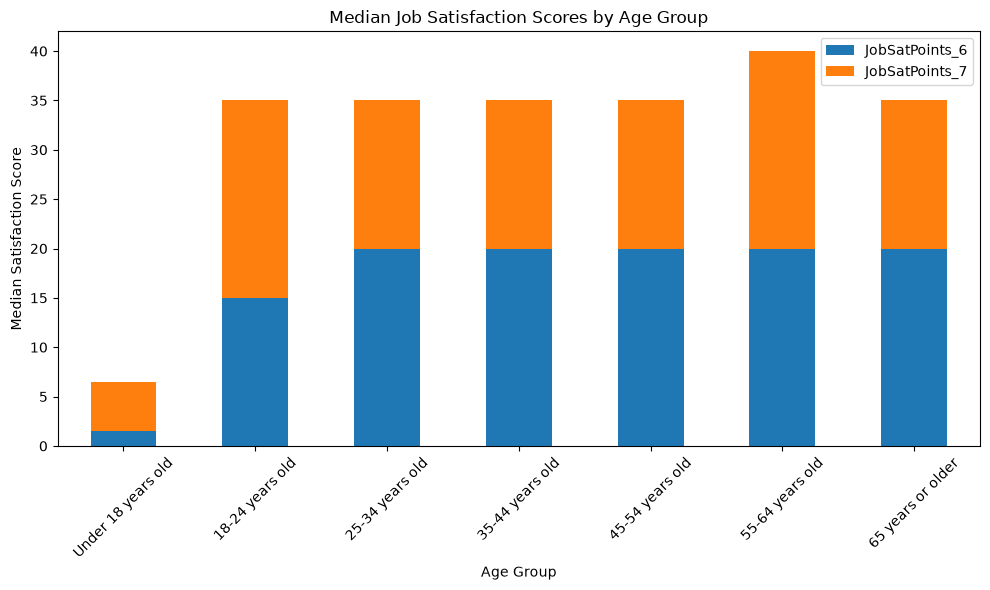

In [7]:
##Write your code here
# Convert Age categories to numeric representative values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df["Age_numeric"] = df["Age"].map(age_mapping)

# Convert satisfaction columns to numeric
df["JobSatPoints_6"] = pd.to_numeric(df["JobSatPoints_6"], errors="coerce")
df["JobSatPoints_7"] = pd.to_numeric(df["JobSatPoints_7"], errors="coerce")

# Calculate median satisfaction scores by age group
age_satisfaction = df.groupby("Age", observed=False)[
    ["JobSatPoints_6", "JobSatPoints_7"]
].median()

# Keep age groups in logical order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

age_satisfaction = age_satisfaction.reindex(age_order)

# Create stacked bar chart
ax = age_satisfaction.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Median Job Satisfaction Scores by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Satisfaction Score")
plt.xticks(rotation=45)
plt.legend(["JobSatPoints_6", "JobSatPoints_7"])
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


/tmp/ipykernel_609/644374211.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

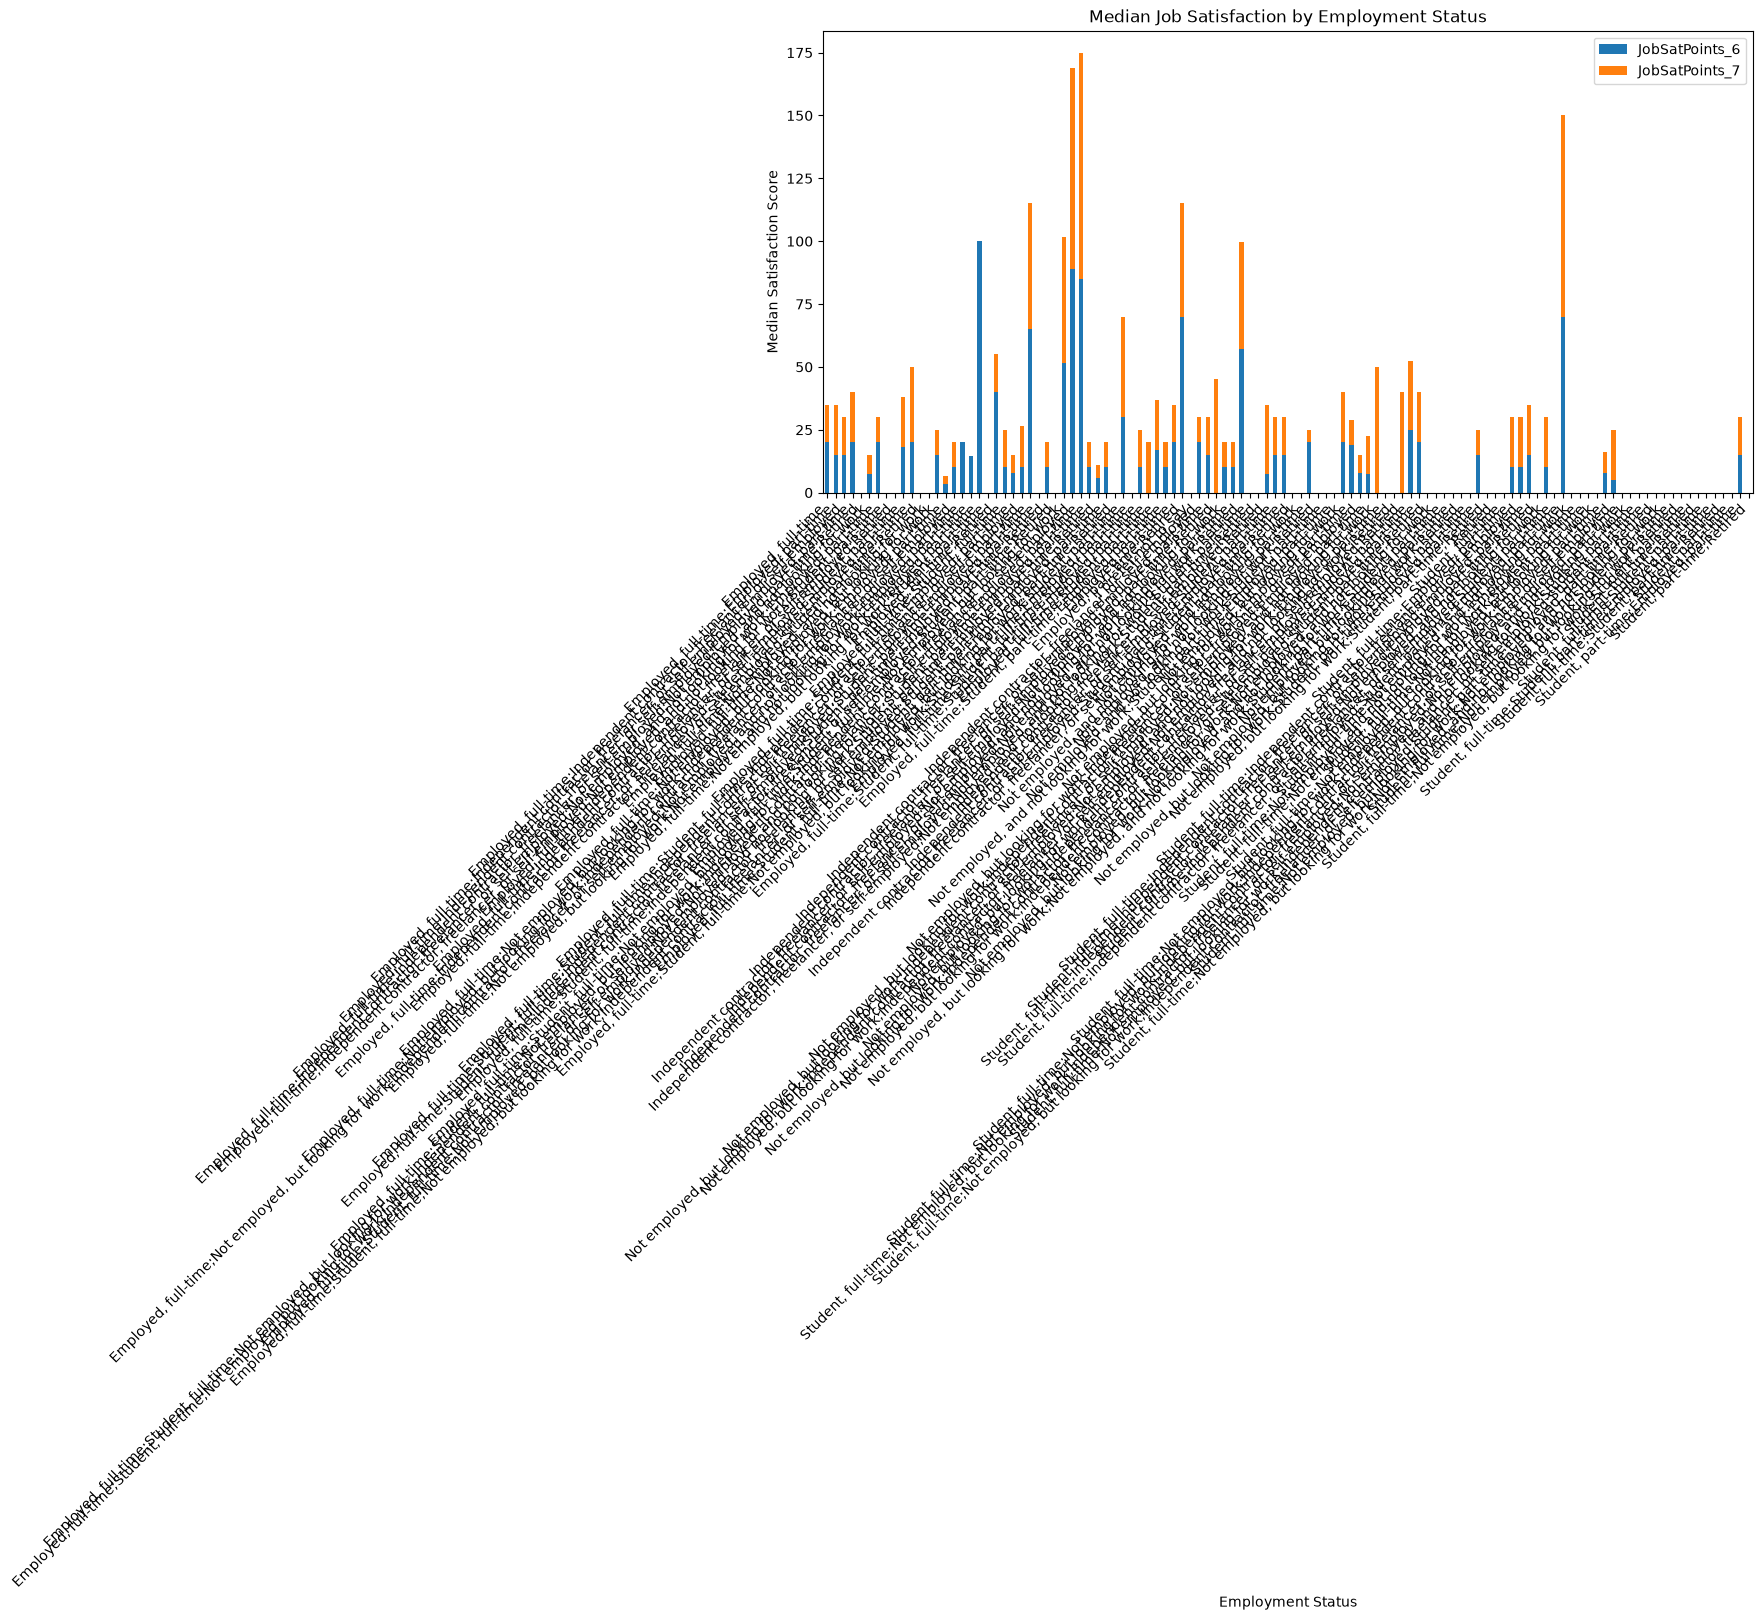

In [8]:
##Write your code here
# Convert satisfaction columns to numeric
df["JobSatPoints_6"] = pd.to_numeric(df["JobSatPoints_6"], errors="coerce")
df["JobSatPoints_7"] = pd.to_numeric(df["JobSatPoints_7"], errors="coerce")

# Calculate median satisfaction by employment status
employment_satisfaction = df.groupby("Employment")[
    ["JobSatPoints_6", "JobSatPoints_7"]
].median()

# Create stacked bar chart
ax = employment_satisfaction.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Median Job Satisfaction by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Median Satisfaction Score")
plt.xticks(rotation=45, ha="right")
plt.legend(["JobSatPoints_6", "JobSatPoints_7"])
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


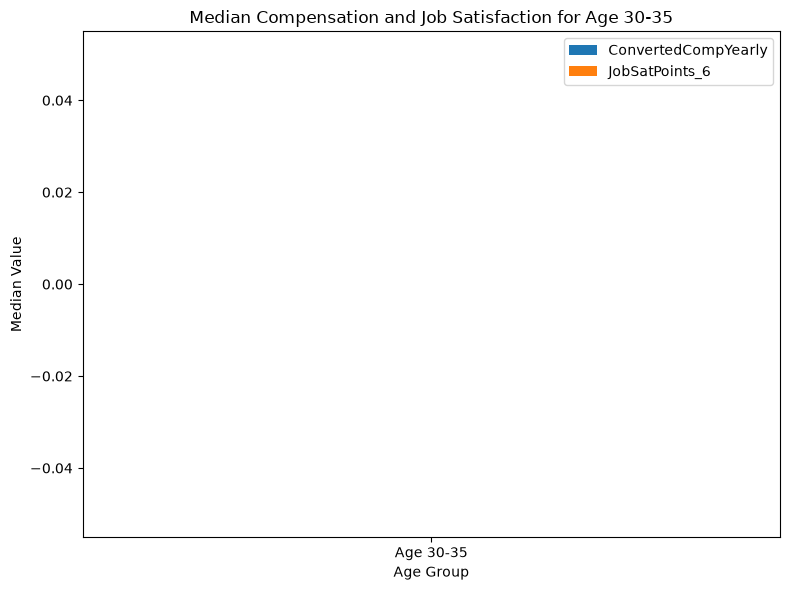

In [9]:
##Write your code here
# Create numeric age representation
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df["Age_numeric"] = df["Age"].map(age_mapping)

# Convert columns to numeric
df["ConvertedCompYearly"] = pd.to_numeric(
    df["ConvertedCompYearly"],
    errors="coerce"
)

df["JobSatPoints_6"] = pd.to_numeric(
    df["JobSatPoints_6"],
    errors="coerce"
)

# Filter approximately for the requested age range
age_30_35 = df[
    (df["Age_numeric"] >= 30) &
    (df["Age_numeric"] <= 35)
].copy()

# Calculate medians
median_compensation = age_30_35["ConvertedCompYearly"].median()
median_satisfaction = age_30_35["JobSatPoints_6"].median()

# Create a small DataFrame for the stacked chart
comparison = pd.DataFrame({
    "ConvertedCompYearly": [median_compensation],
    "JobSatPoints_6": [median_satisfaction]
}, index=["Age 30-35"])

# Create stacked bar chart
comparison.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("Median Compensation and Job Satisfaction for Age 30-35")
plt.xlabel("Age Group")
plt.ylabel("Median Value")
plt.xticks(rotation=0)
plt.legend(["ConvertedCompYearly", "JobSatPoints_6"])
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


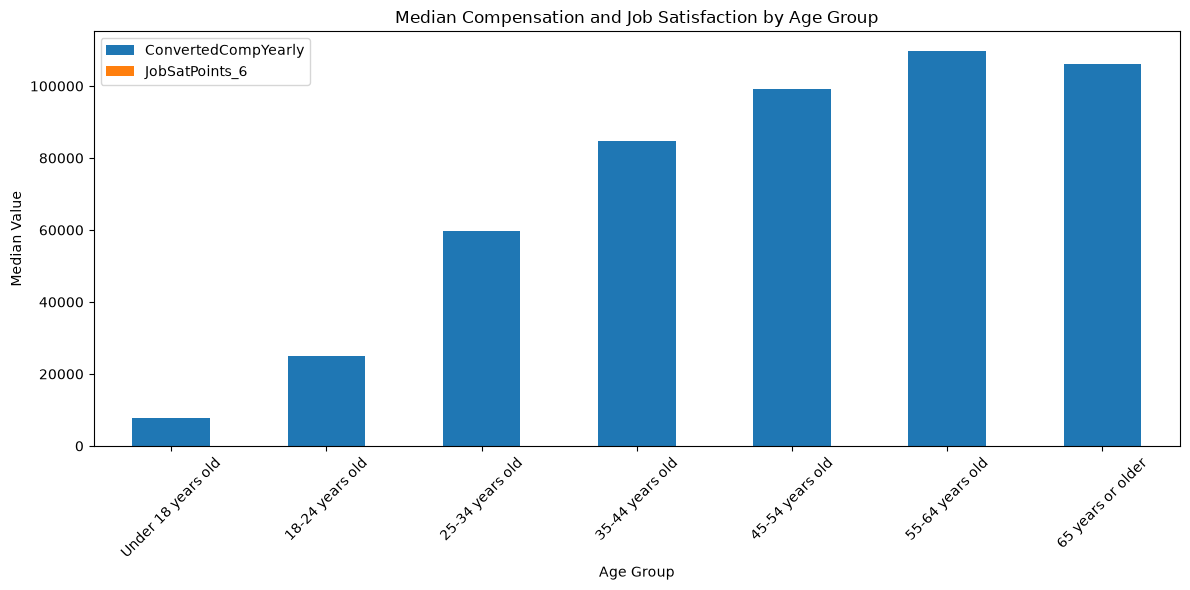

In [10]:
##Write your code here
# Convert columns to numeric
df["ConvertedCompYearly"] = pd.to_numeric(
    df["ConvertedCompYearly"],
    errors="coerce"
)

df["JobSatPoints_6"] = pd.to_numeric(
    df["JobSatPoints_6"],
    errors="coerce"
)

# Calculate median compensation and satisfaction by age
age_compensation_satisfaction = df.groupby("Age")[
    ["ConvertedCompYearly", "JobSatPoints_6"]
].median()

# Order age groups
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

age_compensation_satisfaction = age_compensation_satisfaction.reindex(
    age_order
)

# Create stacked chart
age_compensation_satisfaction.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Median Compensation and Job Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Value")
plt.xticks(rotation=45)
plt.legend(["ConvertedCompYearly", "JobSatPoints_6"])
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


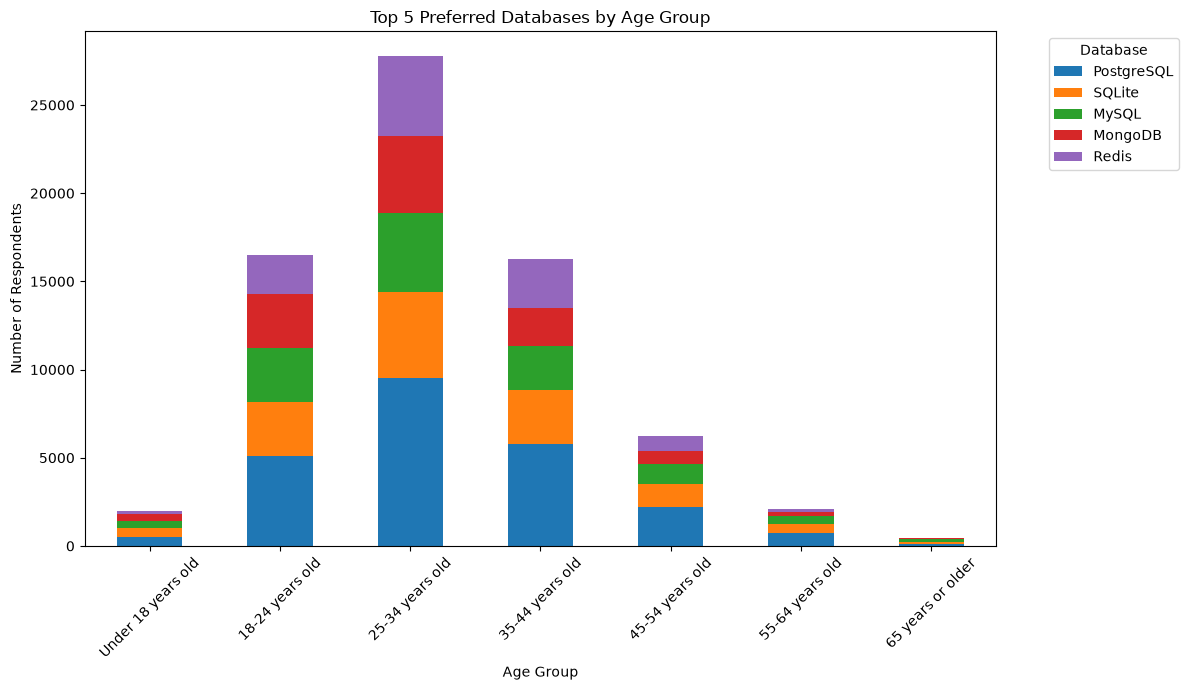

In [12]:
##Write your code here
# Select required columns
database_data = df[
    ["Age", "DatabaseWantToWorkWith"]
].dropna().copy()

# Split multiple database answers
database_data["Database"] = (
    database_data["DatabaseWantToWorkWith"]
    .str.split(";")
)

# Convert each database into a separate row
# Reset index to avoid duplicate-index error
database_data = (
    database_data
    .explode("Database")
    .reset_index(drop=True)
)

# Remove extra spaces
database_data["Database"] = database_data["Database"].str.strip()

# Create count table
database_counts = pd.crosstab(
    database_data["Age"],
    database_data["Database"]
)

# Keep the top 5 databases overall
top_databases = (
    database_data["Database"]
    .value_counts()
    .head(5)
    .index
)

database_counts = database_counts[
    [db for db in top_databases if db in database_counts.columns]
]

# Define age order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Order age groups
database_counts = database_counts.reindex(age_order)

# Replace missing values with 0
database_counts = database_counts.fillna(0)

# Create stacked bar chart
database_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Top 5 Preferred Databases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.legend(
    title="Database",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


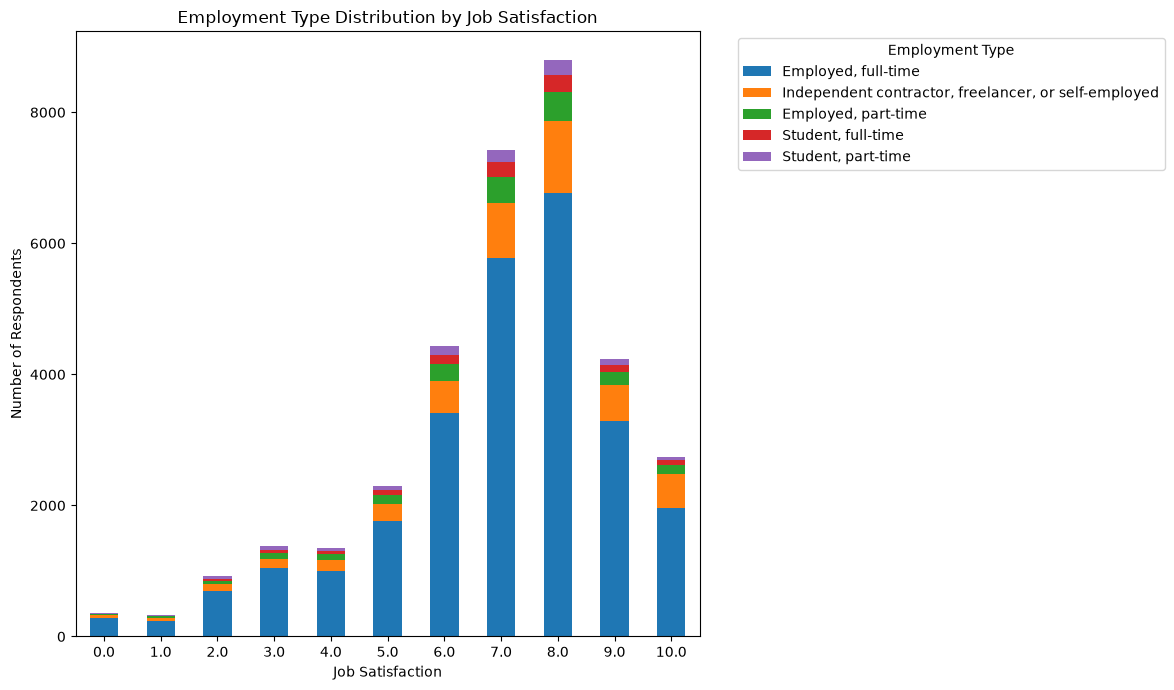

In [14]:
##Write your code here
# Select required columns
employment_job_sat = df[
    ["Employment", "JobSat"]
].dropna().copy()

# Split multiple employment types
employment_job_sat["EmploymentType"] = (
    employment_job_sat["Employment"]
    .str.split(";")
)

# Explode employment types and reset the index
employment_job_sat = (
    employment_job_sat
    .explode("EmploymentType")
    .reset_index(drop=True)
)

# Remove extra spaces
employment_job_sat["EmploymentType"] = (
    employment_job_sat["EmploymentType"]
    .str.strip()
)

# Create count table
employment_counts = pd.crosstab(
    employment_job_sat["JobSat"],
    employment_job_sat["EmploymentType"]
)

# Keep the top 5 employment types
top_employment = (
    employment_job_sat["EmploymentType"]
    .value_counts()
    .head(5)
    .index
)

employment_counts = employment_counts[
    [
        x for x in top_employment
        if x in employment_counts.columns
    ]
]

# Create stacked bar chart
employment_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Employment Type Distribution by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)

plt.legend(
    title="Employment Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


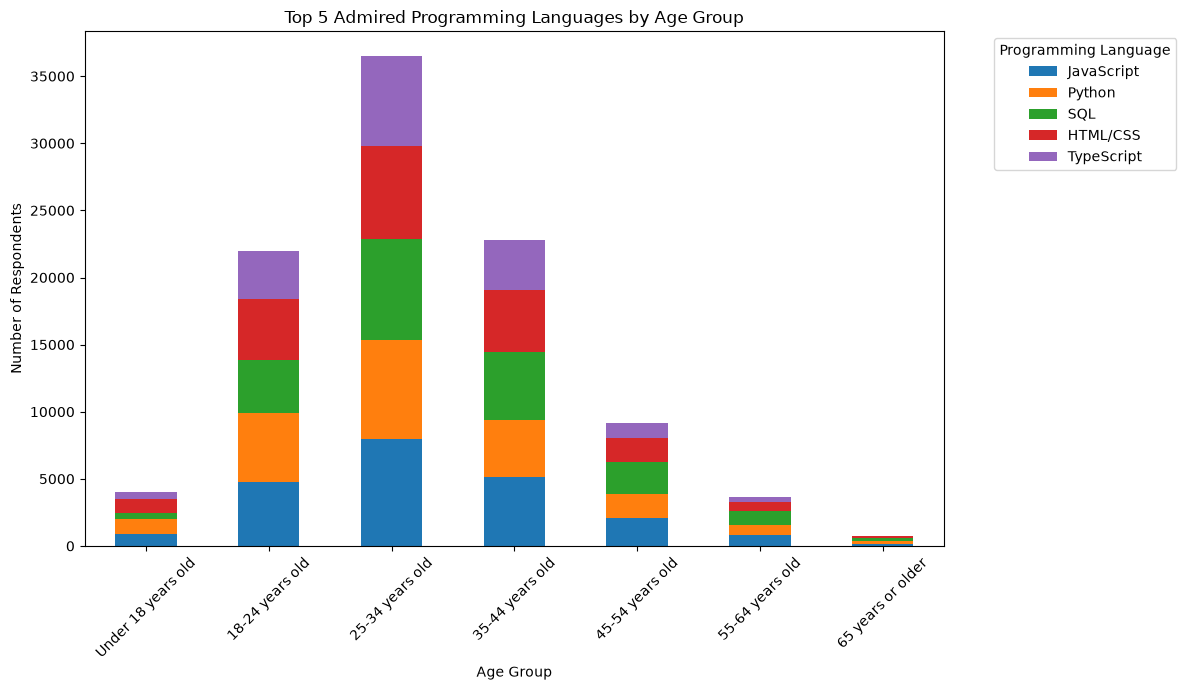

In [16]:
##Write your code here
# Select required columns
language_data = df[
    ["Age", "LanguageAdmired"]
].dropna().copy()

# Split multiple languages
language_data["Language"] = (
    language_data["LanguageAdmired"]
    .str.split(";")
)

# Explode into separate rows and reset index
language_data = (
    language_data
    .explode("Language")
    .reset_index(drop=True)
)

# Remove extra spaces
language_data["Language"] = (
    language_data["Language"]
    .str.strip()
)

# Create count table
language_counts = pd.crosstab(
    language_data["Age"],
    language_data["Language"]
)

# Select top 5 languages overall
top_languages = (
    language_data["Language"]
    .value_counts()
    .head(5)
    .index
)

# Keep only top 5 languages
language_counts = language_counts[
    [
        lang
        for lang in top_languages
        if lang in language_counts.columns
    ]
]

# Define age order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Order age groups
language_counts = language_counts.reindex(age_order)

# Replace missing values with 0
language_counts = language_counts.fillna(0)

# Create stacked bar chart
language_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Top 5 Admired Programming Languages by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)

plt.legend(
    title="Programming Language",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


Platform-related columns found: ['PlatformAdmired']

/tmp/ipykernel_609/446423210.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

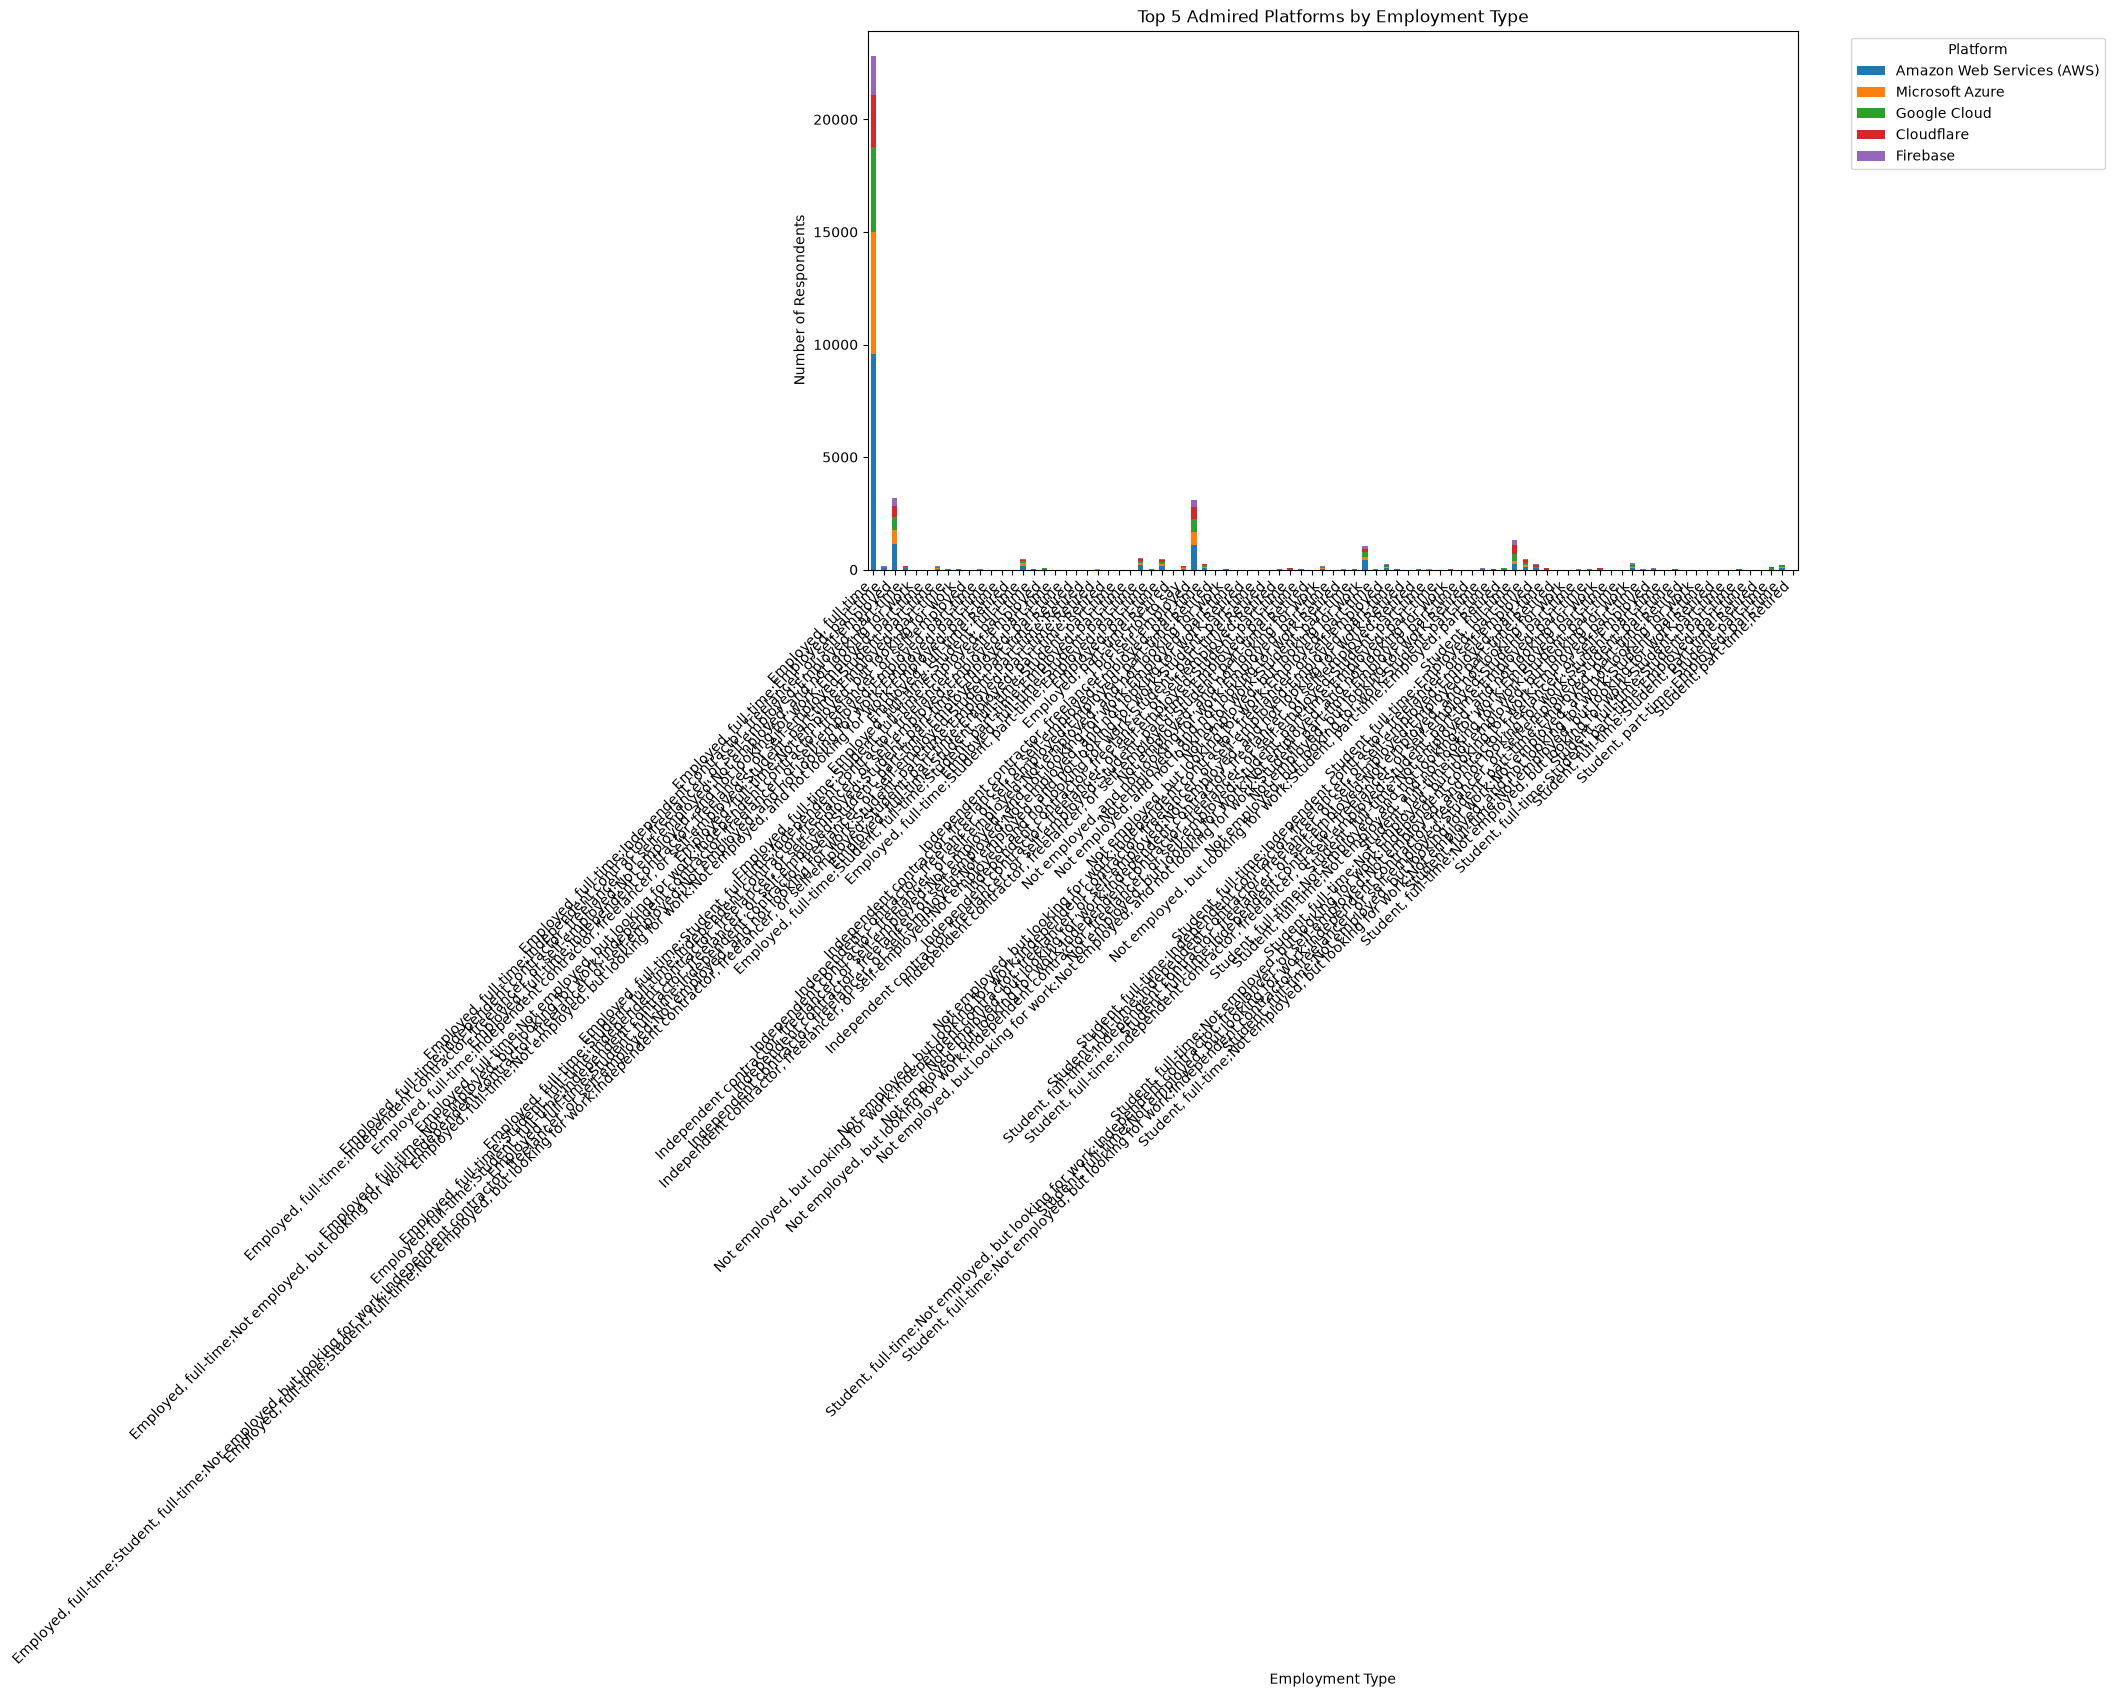

In [18]:
# Check for the PlatformAdmired column
platform_columns = [
    col for col in df.columns
    if "PlatformAdmired" in col
]

print("Platform-related columns found:", platform_columns)

# Use PlatformAdmired if available
if "PlatformAdmired" in df.columns:

    # Select required columns
    platform_data = df[
        ["Employment", "PlatformAdmired"]
    ].dropna().copy()

    # Split multiple platforms
    platform_data["Platform"] = (
        platform_data["PlatformAdmired"]
        .str.split(";")
    )

    # Explode platforms and reset index
    platform_data = (
        platform_data
        .explode("Platform")
        .reset_index(drop=True)
    )

    # Remove extra spaces
    platform_data["Platform"] = (
        platform_data["Platform"]
        .str.strip()
    )

    # Create count table
    platform_counts = pd.crosstab(
        platform_data["Employment"],
        platform_data["Platform"]
    )

    # Select top 5 platforms
    top_platforms = (
        platform_data["Platform"]
        .value_counts()
        .head(5)
        .index
    )

    # Keep only top 5 platforms
    platform_counts = platform_counts[
        [
            platform
            for platform in top_platforms
            if platform in platform_counts.columns
        ]
    ]

    # Create stacked bar chart
    platform_counts.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 7)
    )

    plt.title("Top 5 Admired Platforms by Employment Type")
    plt.xlabel("Employment Type")
    plt.ylabel("Number of Respondents")
    plt.xticks(rotation=45, ha="right")

    plt.legend(
        title="Platform",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

else:
    print("PlatformAdmired column was not found in this dataset.")

    print("Available platform-related columns:")
    print([
        col for col in df.columns
        if "Platform" in col
    ])

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
